In [1]:
data_dir = "/home/mjehangir/telomere-sv-analysis/data/"

In [2]:
setwd(data_dir)

In [3]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package

In [4]:
# Read the CSV file into a data frame
df_cnv <- read.delim("Mean_normalized_v3_tab.seg", header = TRUE)
df_arms <- read.delim("/home/mjehangir/chm13_chrs_arms/cytoBandMapped.bed", header = TRUE)
t2t_telomere = read.csv(file = "chm13v2.0_telomere.bed.txt", header = TRUE, sep = "\t")
# Set column names

In [5]:
# View the data
#df_cnv <- df_cnv %>% select(-Arm)
df_cnv$chrom <- paste0("chr", df_cnv$chrom)

head(df_cnv)
head(df_arms)
head(t2t_telomere)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean
,<chr>,<chr>,<int>,<int>,<int>,<dbl>
1,2436A,chr1,200151,28021140,130,0.0534
2,2436A,chr1,142707663,142907814,2,1.3533
3,2436A,chr10,88303635,101719380,68,0.0066
4,2436A,chr10,101919615,104722905,15,-0.1040
5,2436A,chr10,104923140,112932540,41,-0.0198
6,2436A,chr10,113132775,120741705,39,-0.4022


,chr1,X0,X1735965,p36.33,gneg
,<chr>,<int>,<int>,<chr>,<chr>
1,chr1,1735965,4816989,p36.32,gpos25
2,chr1,4816989,6629068,p36.31,gneg
3,chr1,6629068,8634052,p36.23,gpos25
4,chr1,8634052,12044143,p36.22,gneg
5,chr1,12044143,15341266,p36.21,gpos50
6,chr1,15341266,19923637,p36.13,gneg


,chr1,X0,X3000
,<chr>,<int>,<int>
1,chr1,248384000,248387328
2,chr2,0,3600
3,chr2,242693800,242696752
4,chr3,0,2800
5,chr3,200904400,200905400
6,chr3,201101200,201105948


In [6]:
# Assign column names
colnames(t2t_telomere) <- c("chr", "start", "end")

# View the result
head(t2t_telomere)

,chr,start,end
,<chr>,<int>,<int>
1,chr1,248384000,248387328
2,chr2,0,3600
3,chr2,242693800,242696752
4,chr3,0,2800
5,chr3,200904400,200905400
6,chr3,201101200,201105948


In [7]:
#assign p and q arms to t2t telomeres data
t2t_telomere <- t2t_telomere %>%
  #rename(chrom = V1, telomere_start = V2, telomere_end = V3) %>%
  group_by(chr) %>%
  arrange(start) %>%
  mutate(Arm = case_when(
    row_number() == 1 ~ "p",
    row_number() == n() ~ "q",
    TRUE ~ NA_character_
  )) %>%
  ungroup()
head(t2t_telomere)

chr,start,end,Arm
<chr>,<int>,<int>,<chr>
chr2,0,3600,p
chr3,0,2800,p
chr4,0,3400,p
chr5,0,2400,p
chr6,0,3000,p
chr7,0,3600,p


In [8]:
colnames(df_arms) <- c("chr", "start", "end", "band", "stain")
head(df_arms)

,chr,start,end,band,stain
,<chr>,<int>,<int>,<chr>,<chr>
1,chr1,1735965,4816989,p36.32,gpos25
2,chr1,4816989,6629068,p36.31,gneg
3,chr1,6629068,8634052,p36.23,gpos25
4,chr1,8634052,12044143,p36.22,gneg
5,chr1,12044143,15341266,p36.21,gpos50
6,chr1,15341266,19923637,p36.13,gneg


In [9]:
# Step 2: Create 'arm' column
df_arms <- df_arms %>%
  mutate(arm = ifelse(
    stain == "acen", "centromere",
    ifelse(grepl("^p", band), "p", "q")
  ))

# Step 3: Calculate the size for each row
df_arms <- df_arms %>%
  mutate(size = end - start)

# Step 4: Group by chromosome and arm, and calculate total size, start, and end
df_arms <- df_arms %>%
  group_by(chr, arm) %>%
  summarise(
    total_size = sum(size),
    start = min(start),  # get the first start position for each group
    end = max(end)       # get the last end position for each group
  )

# Step 5: View the results
print(df_arms)

`summarise()` has grouped output by 'chr'. You can override using the `.groups`
argument.


# A tibble: 72 × 5
# Groups:   chr [24]
   chr   arm        total_size     start       end
   <chr> <chr>           <int>     <int>     <int>
 1 chr1  centromere    4504439 121796048 126300487
 2 chr1  p           120060083   1735965 121796048
 3 chr1  q           122086841 126300487 248387328
 4 chr10 centromere    2030796  39633793  41664589
 5 chr10 p            39633793         0  39633793
 6 chr10 q            93093545  41664589 134758134
 7 chr11 centromere    3415049  51035789  54450838
 8 chr11 p            51035789         0  51035789
 9 chr11 q            80676931  54450838 135127769
10 chr12 centromere    2581652  34620838  37202490
# ℹ 62 more rows


In [10]:
# Merge the data
t2t_merged_data <- bind_rows(
  df_arms %>% select(chr, arm, start, end),
  t2t_telomere %>% mutate(arm = paste0(Arm, "_telomere")) %>% select(chr, arm, start, end)
) %>%
  arrange(chr, start)

# View the merged data
head(t2t_merged_data)
#write.table(head(t2t_merged_data), file = "/scratch/mjehangir/chm13_pq_centromere_telomeres.txt", sep = "\t", row.names = FALSE, quote = FALSE)

chr,arm,start,end
<chr>,<chr>,<int>,<int>
chr1,p,1735965,121796048
chr1,centromere,121796048,126300487
chr1,q,126300487,248387328
chr1,p_telomere,248384000,248387328
chr10,p,0,39633793
chr10,p_telomere,0,2800


In [11]:
# Step 3: Assign Gain, Loss, or Neutral based on seg.mean

df_cnv$Gain_Loss <- case_when(
  df_cnv$seg.mean < -0.2 ~ "Loss", ### assuming negative values as loss 
  df_cnv$seg.mean > 0.2 ~ "Gain", ### assuming positive values as gain

  TRUE ~ "Neutral"
)
head(df_cnv)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,Gain_Loss
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>
1,2436A,chr1,200151,28021140,130,0.0534,Neutral
2,2436A,chr1,142707663,142907814,2,1.3533,Gain
3,2436A,chr10,88303635,101719380,68,0.0066,Neutral
4,2436A,chr10,101919615,104722905,15,-0.1040,Neutral
5,2436A,chr10,104923140,112932540,41,-0.0198,Neutral
6,2436A,chr10,113132775,120741705,39,-0.4022,Loss


In [12]:
colnames(df_cnv)


[1] "ID"        "chrom"     "loc.start" "loc.end"   "num.mark"  "seg.mean" 
[7] "Gain_Loss"

In [13]:

cnv_midpoint <- df_cnv %>%
  mutate(
    start = as.numeric(`loc.start`),
    end = as.numeric(`loc.end`),
    midpoint = (start + end) / 2
  )
head(cnv_midpoint)


,ID,chrom,loc.start,loc.end,num.mark,seg.mean,Gain_Loss,start,end,midpoint
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1,2436A,chr1,200151,28021140,130,0.0534,Neutral,200151,28021140,14110646
2,2436A,chr1,142707663,142907814,2,1.3533,Gain,142707663,142907814,142807738
3,2436A,chr10,88303635,101719380,68,0.0066,Neutral,88303635,101719380,95011508
4,2436A,chr10,101919615,104722905,15,-0.1040,Neutral,101919615,104722905,103321260
5,2436A,chr10,104923140,112932540,41,-0.0198,Neutral,104923140,112932540,108927840
6,2436A,chr10,113132775,120741705,39,-0.4022,Loss,113132775,120741705,116937240


In [14]:
# Normalize CNVs along the entire chromosome from telomere to telomere
cnv_norm_telomere <- cnv_midpoint %>%
  left_join(df_arms %>% filter(arm == "p") %>% select(chr, start, end) %>% rename(start.p = start, end.p = end), by = c("chrom" = "chr")) %>%
  left_join(df_arms %>% filter(arm == "q") %>% select(chr, start, end) %>% rename(start.q = start, end.q = end), by = c("chrom" = "chr")) %>%
  left_join(df_arms %>% filter(arm == "centromere") %>% select(chr, start) %>% rename(start.centromere = start), by = c("chrom" = "chr")) %>%
  mutate(
    scaled_pos = (midpoint - start.p) / (end.q - start.p),      # Normalize the CNV position by scaling it between p-arm telomere (0) and q-arm telomere (1)
    centromere_pos = (start.centromere - start.p) / (end.q - start.p),  # Calculate the centromere position on the same scale (proportion between p-arm and q-arm)
    Gain_Loss = factor(Gain_Loss, levels = c("Gain", "Loss"))  # Set "Gain" and "Loss" as levels for the 'Gain_Loss' factor, ensuring consistent legend ordering
  ) %>%
  filter(!is.na(scaled_pos))  # Remove any CNVs where the scaling process resulted in missing values (e.g., CNVs within centromere)
head(cnv_norm_telomere)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,Gain_Loss,start,end,midpoint,start.p,end.p,start.q,end.q,start.centromere,scaled_pos,centromere_pos
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
1,2436A,chr1,200151,28021140,130,0.0534,NA,200151,28021140,14110646,1735965,121796048,126300487,248387328,121796048,0.05017074,0.4867603
2,2436A,chr1,142707663,142907814,2,1.3533,Gain,142707663,142907814,142807738,1735965,121796048,126300487,248387328,121796048,0.57194808,0.4867603
3,2436A,chr10,88303635,101719380,68,0.0066,NA,88303635,101719380,95011508,0,39633793,41664589,134758134,39633793,0.70505212,0.2941106
4,2436A,chr10,101919615,104722905,15,-0.1040,NA,101919615,104722905,103321260,0,39633793,41664589,134758134,39633793,0.76671632,0.2941106
5,2436A,chr10,104923140,112932540,41,-0.0198,NA,104923140,112932540,108927840,0,39633793,41664589,134758134,39633793,0.80832108,0.2941106
6,2436A,chr10,113132775,120741705,39,-0.4022,Loss,113132775,120741705,116937240,0,39633793,41664589,134758134,39633793,0.86775645,0.2941106


In [15]:
# Filter out rows where Gain_Loss is NA
cnv_norm_telomere <- cnv_norm_telomere %>%
  filter(!is.na(Gain_Loss))
head(cnv_norm_telomere)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,Gain_Loss,start,end,midpoint,start.p,end.p,start.q,end.q,start.centromere,scaled_pos,centromere_pos
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
1,2436A,chr1,142707663,142907814,2,1.3533,Gain,142707663,142907814,142807738,1735965,121796048,126300487,248387328,121796048,0.5719481,0.4867603
2,2436A,chr10,113132775,120741705,39,-0.4022,Loss,113132775,120741705,116937240,0,39633793,41664589,134758134,39633793,0.8677565,0.2941106
3,2436A,chr10,123144525,124546170,8,-0.2972,Loss,123144525,124546170,123845348,0,39633793,41664589,134758134,39633793,0.9190195,0.2941106
4,2436A,chr10,124746405,134357666,48,-0.4613,Loss,124746405,134357666,129552036,0,39633793,41664589,134758134,39633793,0.9613671,0.2941106
5,2436A,chr15,18027720,19630184,6,0.3728,Gain,18027720,19630184,18828952,0,16678794,17694466,99753195,16678794,0.1887554,0.1672006
6,2436A,chr18,39469935,39670290,2,-0.4876,Loss,39469935,39670290,39570112,0,15965699,20933550,80542538,15965699,0.4912946,0.1982269


In [21]:
sv_data = read.csv(file = "/home/mjehangir/telomere-sv-analysis/data/celllines_somatic_with_pq_arms.txt", sep = '\t', header = TRUE)
head(sv_data)

,chr,start,end,arm_size,type,filename,sv_size,arm
,<chr>,<int>,<int>,<int>,<chr>,<int>,<int>,<chr>
1,chr1,14446774,14452051,124048267,DEL,266,5277,p
2,chr1,100485651,100485651,124048267,BND,266,11647876,p
3,chr1,112133527,112133527,124048267,BND,266,11647876,p
4,chr1,116611185,116611185,124048267,BND,266,27966672,p
5,chr1,116611187,116611187,124048267,BND,266,27968006,p
6,chr1,144577857,144577857,124339061,BND,266,27966672,q


In [22]:
sv_data <- sv_data[, 1:]  # keep only relevant columns
head(sv_data)

ERROR: Error in parse(text = input): <text>:1:24: unexpected ']'
1: sv_data <- sv_data[, 1:]
                           ^


In [23]:
sv_data$type <- as.character(sv_data$type)

sv_data <- sv_data %>%
  #mutate(size = abs(as.numeric(end) - as.numeric(start))) %>%  # Recalculate size in base pairs
  filter(size > 50)

ERROR: [1m[33mError[39m in `filter()`:[22m
[1m[22m[36mℹ[39m In argument: `size > 50`.
[1mCaused by error:[22m
[33m![39m object 'size' not found


In [24]:
# First, fix types for start/end in sv_data_clean
sv_data_clean <- sv_data %>%
  mutate(
    start = as.numeric(start),
    end = as.numeric(end)
  )

# Join separate arm coordinates safely
sv_scaled <- sv_data_clean %>%
  select(-arm) %>%  # remove existing 'arm' column if present
  left_join(
    df_arms %>% filter(arm == "p") %>% select(chr, start_p = start), 
    by = "chr"
  ) %>%
  left_join(
    df_arms %>% filter(arm == "q") %>% select(chr, end_q = end), 
    by = "chr"
  ) %>%
  left_join(
    df_arms %>% filter(arm == "centromere") %>% select(chr, centromere_start = start), 
    by = "chr"
  ) %>%
  mutate(
    midpoint = (start + end) / 2,
    scaled_pos = (midpoint - start_p) / (end_q - start_p),
    centromere_pos = if_else(
      !is.na(centromere_start) & !is.na(start_p) & !is.na(end_q),
      (centromere_start - start_p) / (end_q - start_p),
      NA_real_
    )
  ) %>%
  filter(!is.na(scaled_pos))


In [25]:
unique(sv_data_clean$V4)

NULL

In [26]:
head(sv_data_clean)

,chr,start,end,arm_size,type,filename,sv_size,arm
,<chr>,<dbl>,<dbl>,<int>,<chr>,<int>,<int>,<chr>
1,chr1,14446774,14452051,124048267,DEL,266,5277,p
2,chr1,100485651,100485651,124048267,BND,266,11647876,p
3,chr1,112133527,112133527,124048267,BND,266,11647876,p
4,chr1,116611185,116611185,124048267,BND,266,27966672,p
5,chr1,116611187,116611187,124048267,BND,266,27968006,p
6,chr1,144577857,144577857,124339061,BND,266,27966672,q


In [27]:
head(sv_scaled)

,chr,start,end,arm_size,type,filename,sv_size,start_p,end_q,centromere_start,midpoint,scaled_pos,centromere_pos
,<chr>,<dbl>,<dbl>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
1,chr1,14446774,14452051,124048267,DEL,266,5277,1735965,248387328,121796048,14449412,0.0515442,0.4867603
2,chr1,100485651,100485651,124048267,BND,266,11647876,1735965,248387328,121796048,100485651,0.4003614,0.4867603
3,chr1,112133527,112133527,124048267,BND,266,11647876,1735965,248387328,121796048,112133527,0.4475855,0.4867603
4,chr1,116611185,116611185,124048267,BND,266,27966672,1735965,248387328,121796048,116611185,0.4657392,0.4867603
5,chr1,116611187,116611187,124048267,BND,266,27968006,1735965,248387328,121796048,116611187,0.4657393,0.4867603
6,chr1,144577857,144577857,124339061,BND,266,27966672,1735965,248387328,121796048,144577857,0.5791247,0.4867603


In [28]:
head(sv_data_clean)

,chr,start,end,arm_size,type,filename,sv_size,arm
,<chr>,<dbl>,<dbl>,<int>,<chr>,<int>,<int>,<chr>
1,chr1,14446774,14452051,124048267,DEL,266,5277,p
2,chr1,100485651,100485651,124048267,BND,266,11647876,p
3,chr1,112133527,112133527,124048267,BND,266,11647876,p
4,chr1,116611185,116611185,124048267,BND,266,27966672,p
5,chr1,116611187,116611187,124048267,BND,266,27968006,p
6,chr1,144577857,144577857,124339061,BND,266,27966672,q


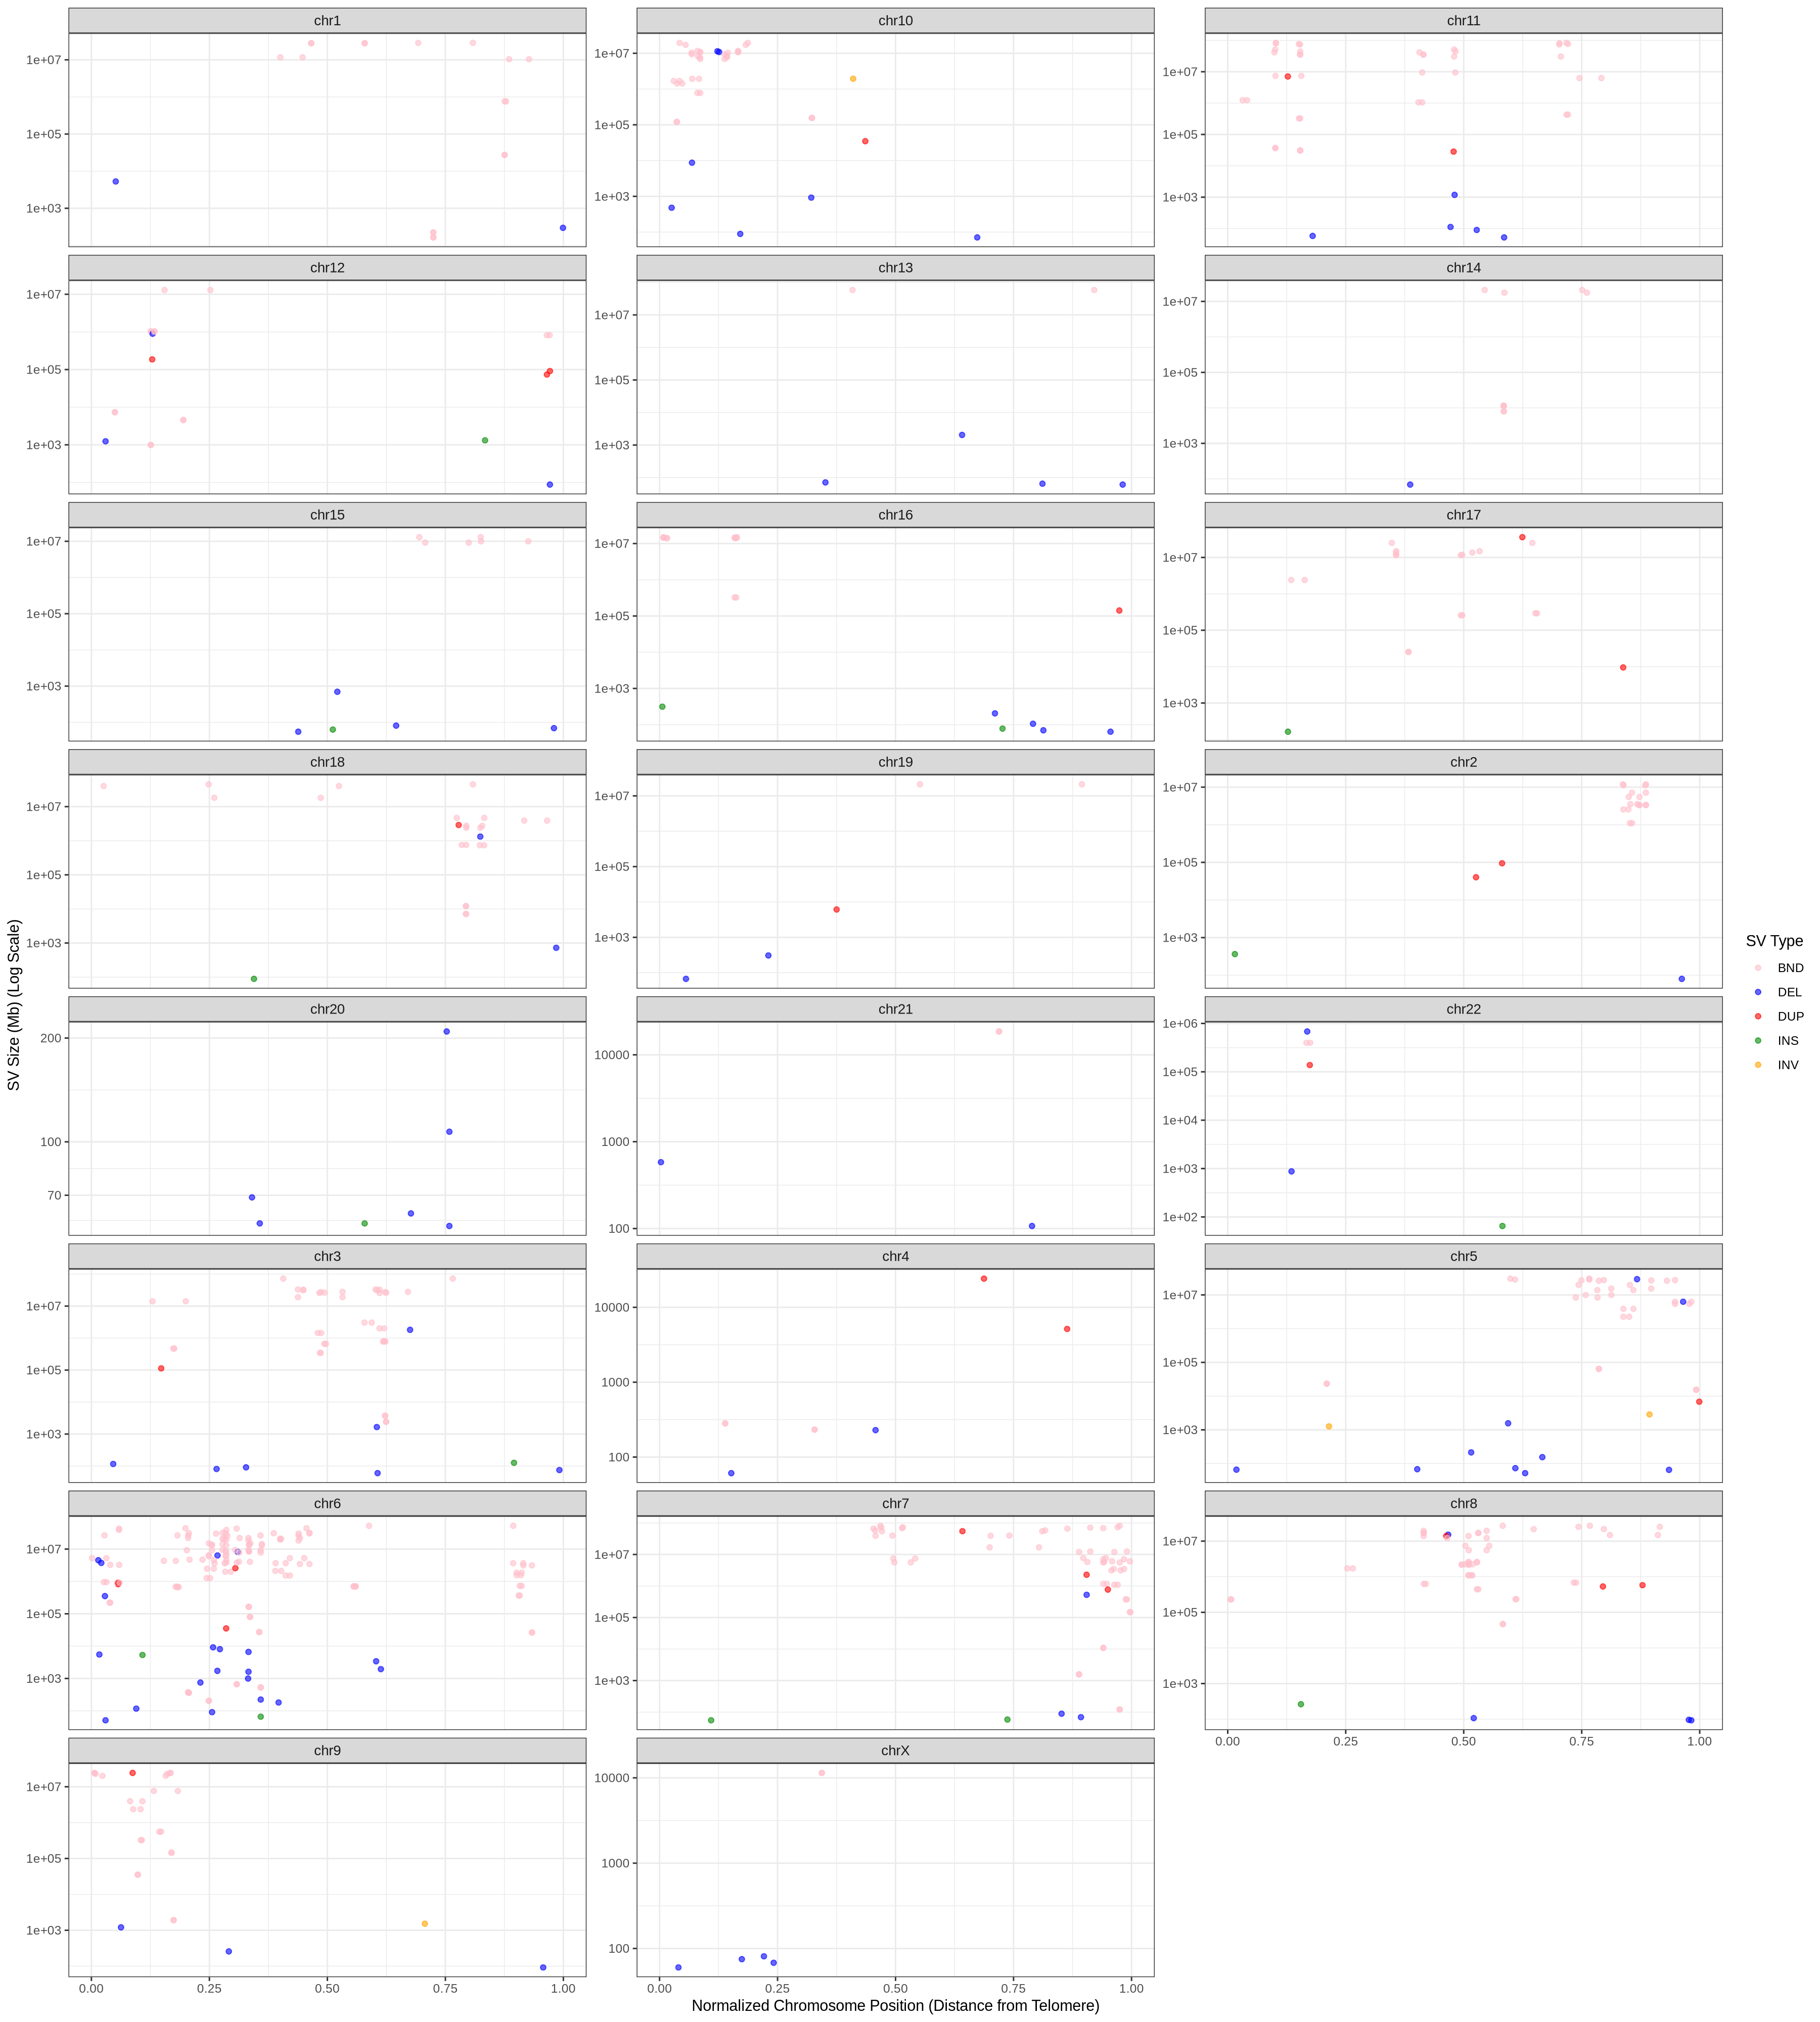

In [29]:
options(repr.plot.width = 18, repr.plot.height = 20, repr.plot.res = 200)

ggplot(sv_scaled, aes(x = scaled_pos, y = sv_size, color = type)) +
  geom_point(alpha = 0.6) +  # Plot individual SVs
  scale_color_manual(values = c("DEL" = "blue", "DUP" = "red", "INS" = "green4", "INV" = "orange", "BND" = "pink")) +
  facet_wrap(~chr, scales = "free_y", ncol = 3) +  # 3 columns per row
  scale_y_log10() +  # Log scale for SV size to handle wide range of sizes
  labs(x = "Normalized Chromosome Position (Distance from Telomere)",
       y = "SV Size (Mb) (Log Scale)",
       color = "SV Type") +
  theme_bw() +
  theme(strip.text = element_text(size = 10))  # Adjust for clear labels



Centromeric       Other   Telomeric 
          8          73          17 


	Wilcoxon rank sum test with continuity correction

data:  sv_size by telomere_group
W = 601.5, p-value = 0.8487
alternative hypothesis: true location shift is not equal to 0



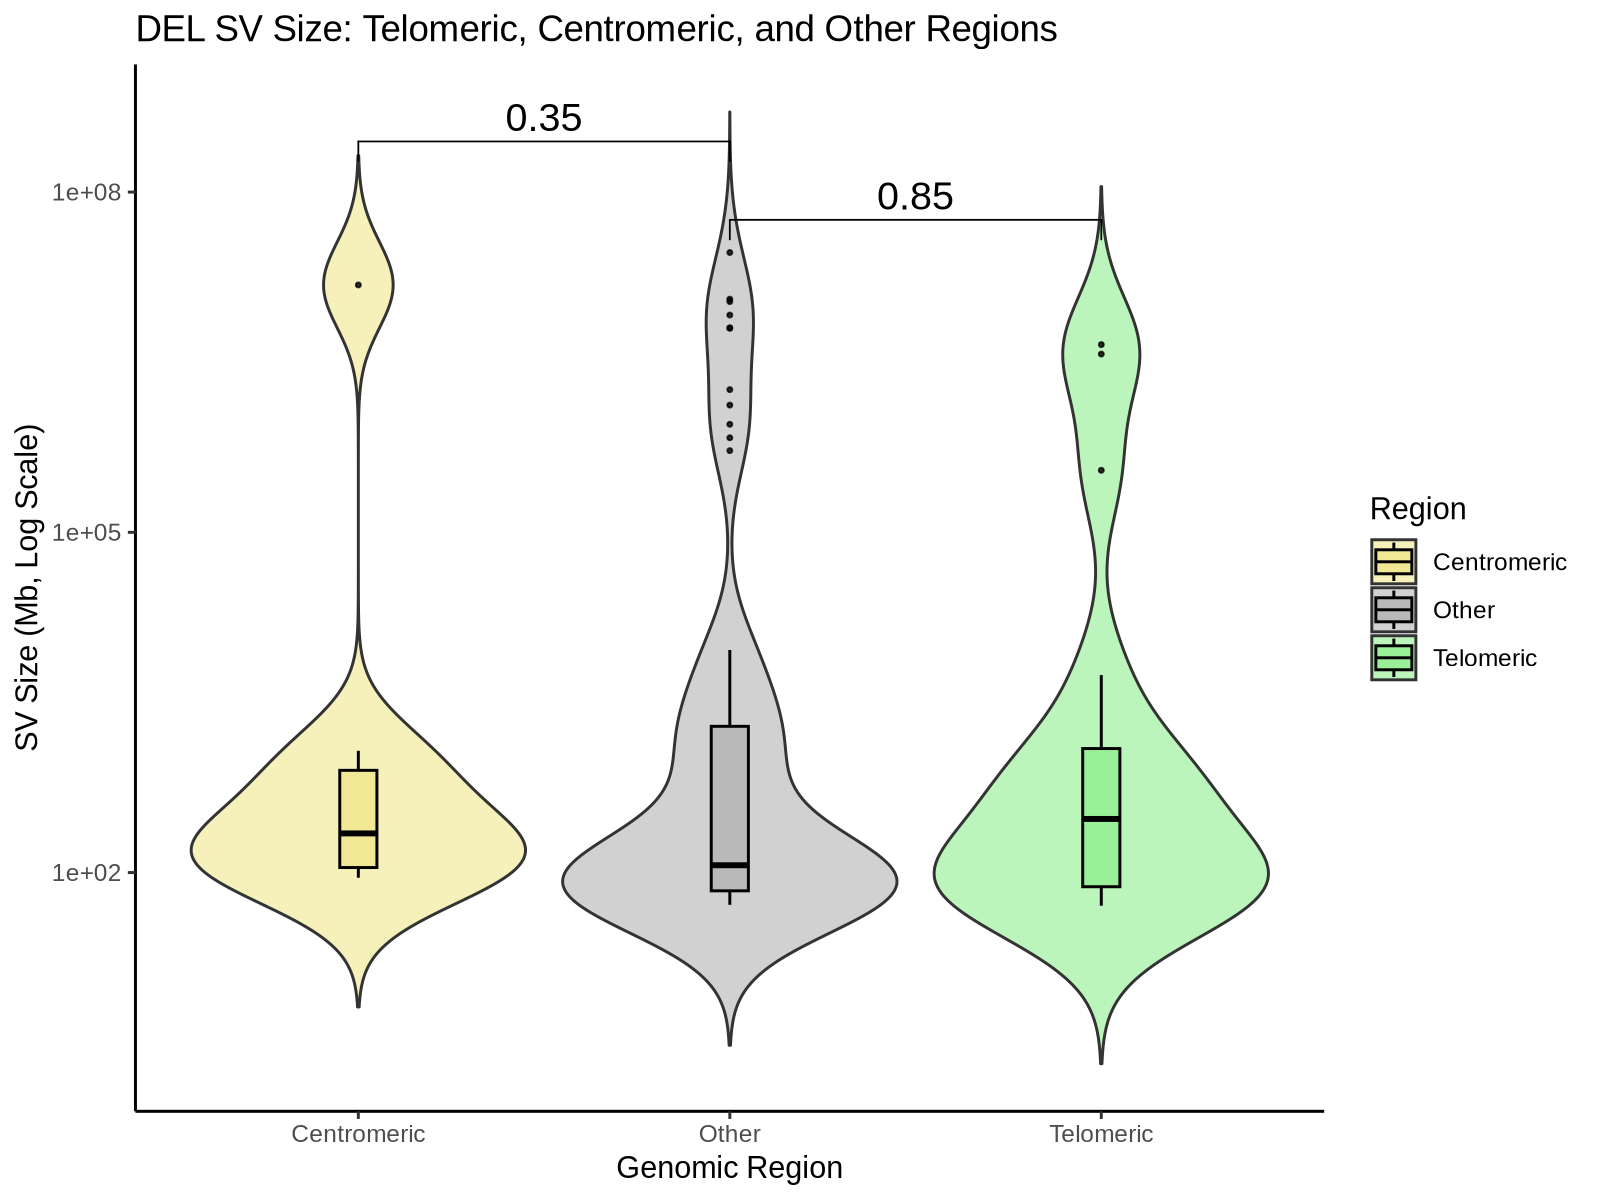

In [31]:
library(dplyr)
library(ggplot2)
library(ggpubr)

# Filter DEL only and classify regions
sv_del <- sv_scaled %>%
  filter(type == "DEL") %>%
  mutate(
    telomere_group = case_when(
      scaled_pos <= 0.03 ~ "Telomeric",
      scaled_pos >= 0.97 ~ "Telomeric",
      scaled_pos > 0.45 & scaled_pos < 0.55 ~ "Centromeric",
      TRUE ~ "Other"
    )
  )

# Check group counts
table(sv_del$telomere_group)

# Wilcoxon test (optional, here just between Telomeric and Other)
wilcox_res <- wilcox.test(sv_size ~ telomere_group, data = sv_del %>% filter(telomere_group != "Centromeric"))
print(wilcox_res)

options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 200)

# Violin plot with 3 groups
p<- ggplot(sv_del, aes(x = telomere_group, y = sv_size, fill = telomere_group)) +
  geom_violin(alpha = 0.6, scale = "width", trim = FALSE) +
  geom_boxplot(width = 0.1, outlier.size = 0.5, alpha = 0.8, color = "black") +
  scale_y_log10() +
  scale_fill_manual(values = c(
    "Telomeric" = "lightgreen",
    "Centromeric" = "khaki",
    "Other" = "gray70"
  )) +
  stat_compare_means(method = "wilcox.test", label.y.npc = "top", size = 5, 
                     comparisons = list(c("Telomeric", "Other"), c("Centromeric", "Other"))) +
  labs(
    title = "DEL SV Size: Telomeric, Centromeric, and Other Regions",
    x = "Genomic Region",
    y = "SV Size (Mb, Log Scale)",
    fill = "Region"
  ) +
  theme_classic()
p

In [32]:
#ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig5/SV_per_region_size.pdf", plot = p, width = 8, height = 6)


In [33]:
#sv_scaled <- sv_scaled[sv_scaled$type != "BND", ]


In [34]:
# Order chromosomes naturally: chr1–chr22, chrX, chrY (if present)
sv_scaled <- sv_scaled %>%
  mutate(chr = factor(chr, levels = paste0("chr", c(1:22, "X", "Y")))) %>%
  filter(!is.na(chr))  # Remove any unmatched chromosomes


Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”
Warning message:
“Groups with fewer than two data points have been dropped.”

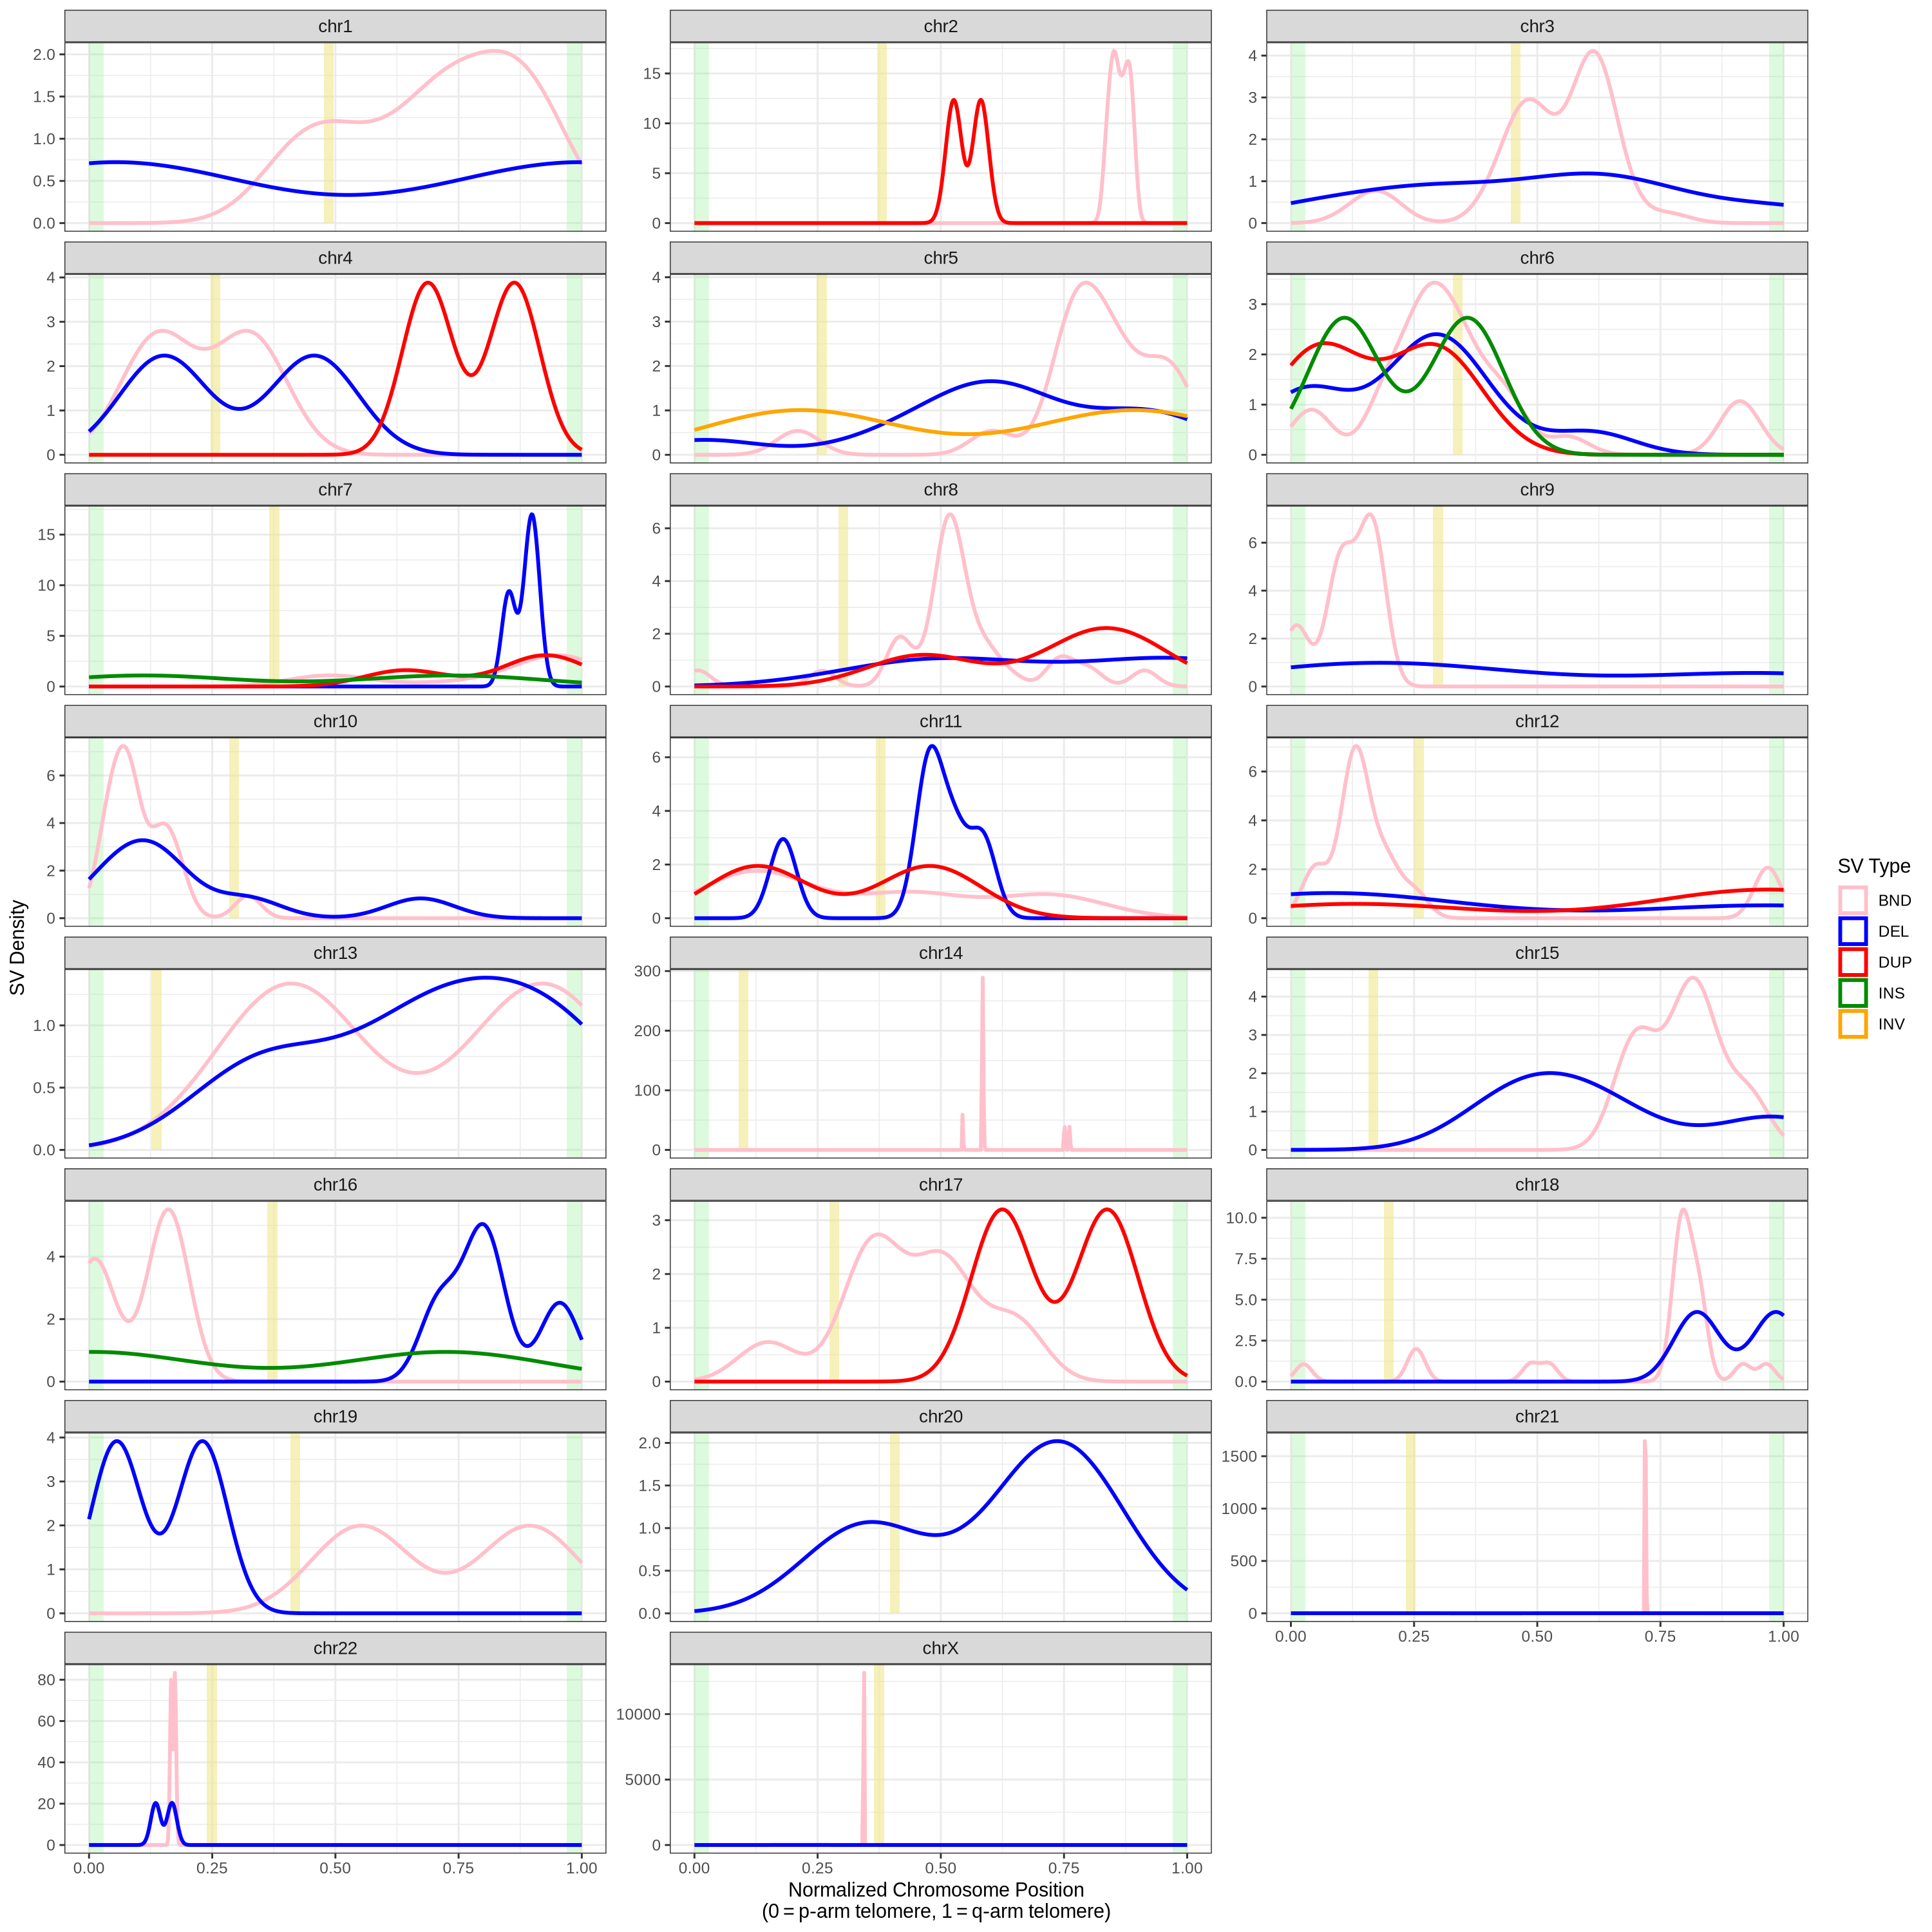

In [35]:
library(ggplot2)
library(dplyr)

# Define the peritelomeric cutoff
peritel_pct <- 0.03

# Precompute a summary of centromere positions per chromosome
cent_data <- sv_scaled %>%
  distinct(chr, centromere_pos) %>%
  filter(!is.na(centromere_pos))

options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 200)
#pdf("/home/mjehangir/telomere-sv-analysis/plots/fig5/severus_sv_whole_genome_distance-ALL_chr.pdf", width = 15, height = 15)

ggplot(sv_scaled, aes(x = scaled_pos, color = type)) +
  # Telomeric & peritelomeric highlight (both ends)
  annotate(
    "rect",
    xmin = 0, xmax = peritel_pct,
    ymin = -Inf, ymax = Inf,
    fill = "lightgreen", alpha = 0.3
  ) +
  annotate(
    "rect",
    xmin = 1 - peritel_pct, xmax = 1,
    ymin = -Inf, ymax = Inf,
    fill = "lightgreen", alpha = 0.3
  ) +
  # Centromere highlight
  geom_rect(
    data = cent_data,
    aes(
      xmin = centromere_pos - 0.01,
      xmax = centromere_pos + 0.01,
      ymin = 0, ymax = Inf
    ),
    fill = "khaki", alpha = 0.6,
    inherit.aes = FALSE
  ) +
  # Density curves
  geom_density(adjust = 1, size = 1, fill = NA) +
  scale_color_manual(values = c(
    "DEL" = "blue",
    "DUP" = "red",
    "INS" = "green4",
    "INV" = "orange",
          "BND" = "pink"

  )) +
  facet_wrap(~chr, scales = "free_y", ncol = 3) +
  labs(
    x = "Normalized Chromosome Position\n(0 = p‑arm telomere, 1 = q‑arm telomere)",
    y = "SV Density",
    color = "SV Type"
  ) +
  theme_bw() +
  theme(
    strip.text = element_text(size = 10)
  )
#dev.off()

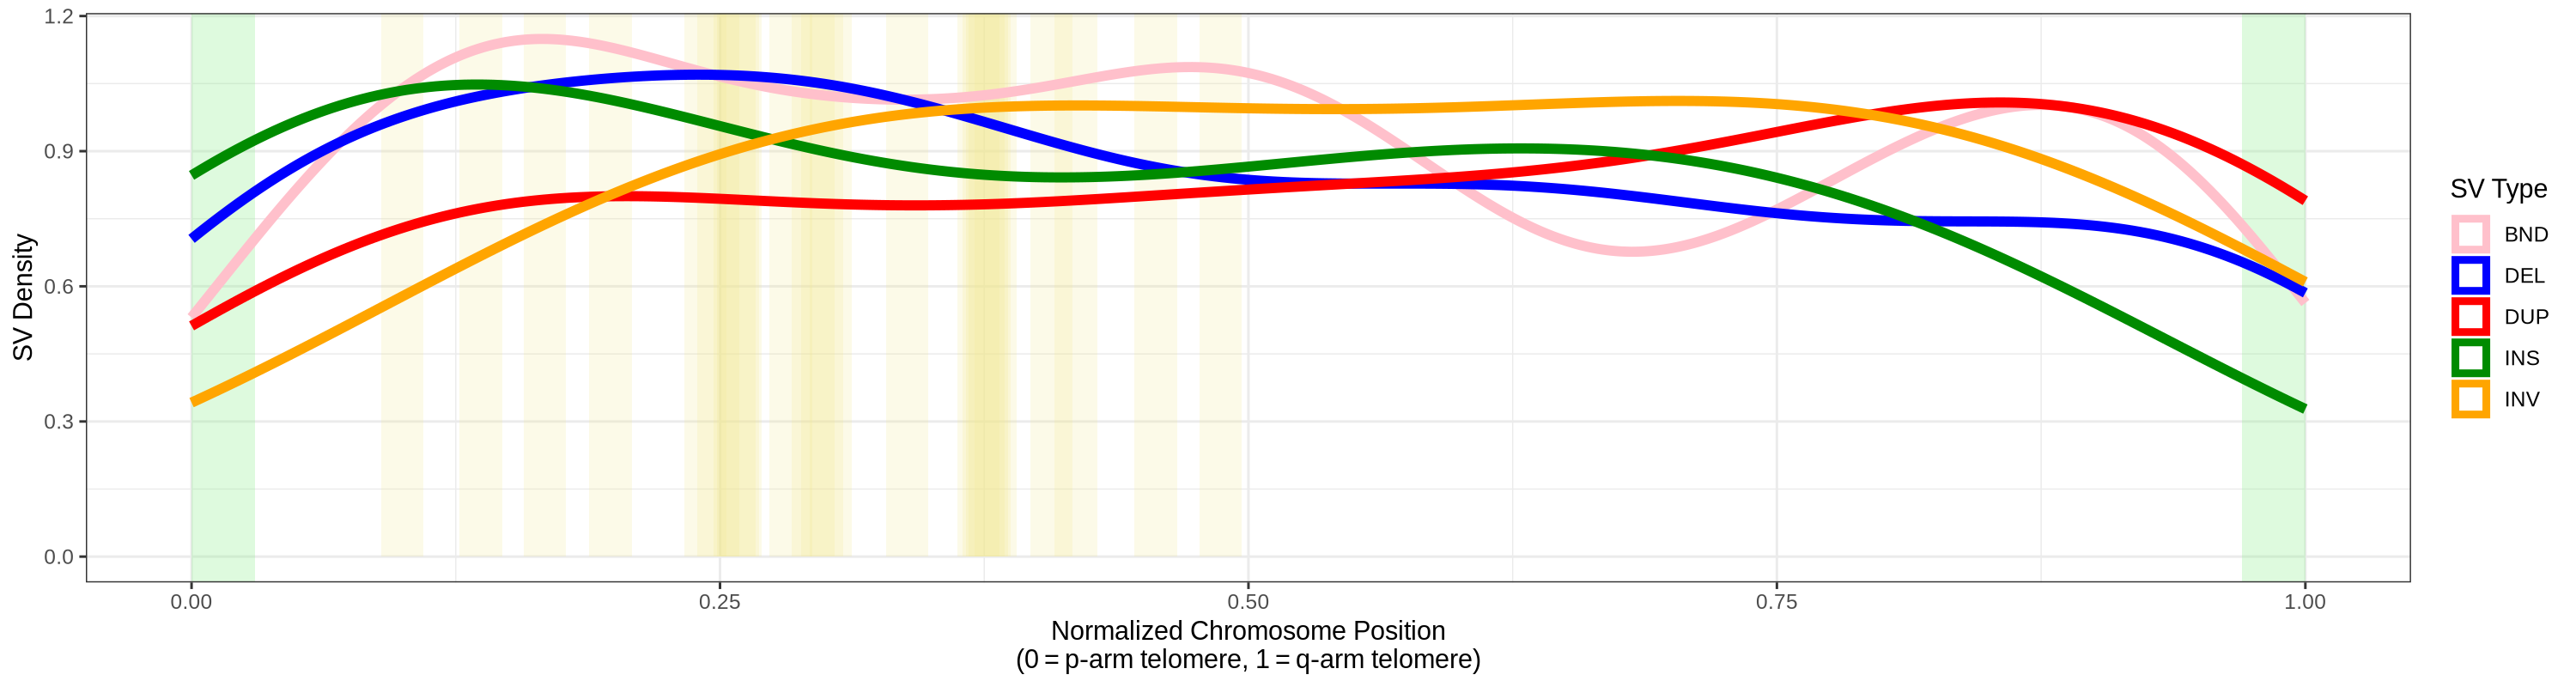

In [36]:
options(repr.plot.width = 15, repr.plot.height = 4, repr.plot.res = 200)
#pdf("/home/mjehangir/telomere-sv-analysis/plots/fig5/severus_sv_whole_genome_distance.pdf", width = 15, height = 4)

# Define peritelomeric cutoff (3% at each end)
peritel_pct <- 0.03

# Precompute centromere positions per chromosome
cent_data <- sv_scaled %>%
  distinct(chr, centromere_pos) %>%
  filter(!is.na(centromere_pos))

ggplot(sv_scaled, aes(x = scaled_pos, color = type)) +
  # Telomeric + peritelomeric shading (both ends)
  annotate(
    "rect",
    xmin = 0, xmax = peritel_pct,
    ymin = -Inf, ymax = Inf,
    fill = "lightgreen", alpha = 0.3
  ) +
  annotate(
    "rect",
    xmin = 1 - peritel_pct, xmax = 1,
    ymin = -Inf, ymax = Inf,
    fill = "lightgreen", alpha = 0.3
  ) +
  # Centromere shading
  geom_rect(
    data = cent_data,
    aes(
      xmin = centromere_pos - 0.01,
      xmax = centromere_pos + 0.01,
      ymin = 0, ymax = Inf
    ),
    fill = "khaki", alpha = 0.2,
    inherit.aes = FALSE
  ) +
  # Density curves
  geom_density(adjust = 1, size = 2, fill = NA) +
  scale_color_manual(values = c(
    "DEL" = "blue",
    "DUP" = "red",
    "INS" = "green4",
    "INV" = "orange",
    "BND" = "pink"

  )) +
  labs(
    x     = "Normalized Chromosome Position\n(0 = p‑arm telomere, 1 = q‑arm telomere)",
    y     = "SV Density",
    color = "SV Type"
  ) +
  theme_bw()
#dev.off()

In [37]:
colnames(sv_scaled)


[1] "chr"              "start"            "end"              "arm_size"        
 [5] "type"             "filename"         "sv_size"          "start_p"         
 [9] "end_q"            "centromere_start" "midpoint"         "scaled_pos"      
[13] "centromere_pos"

In [38]:
head(sv_scaled)

,chr,start,end,arm_size,type,filename,sv_size,start_p,end_q,centromere_start,midpoint,scaled_pos,centromere_pos
,<fct>,<dbl>,<dbl>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
1,chr1,14446774,14452051,124048267,DEL,266,5277,1735965,248387328,121796048,14449412,0.0515442,0.4867603
2,chr1,100485651,100485651,124048267,BND,266,11647876,1735965,248387328,121796048,100485651,0.4003614,0.4867603
3,chr1,112133527,112133527,124048267,BND,266,11647876,1735965,248387328,121796048,112133527,0.4475855,0.4867603
4,chr1,116611185,116611185,124048267,BND,266,27966672,1735965,248387328,121796048,116611185,0.4657392,0.4867603
5,chr1,116611187,116611187,124048267,BND,266,27968006,1735965,248387328,121796048,116611187,0.4657393,0.4867603
6,chr1,144577857,144577857,124339061,BND,266,27966672,1735965,248387328,121796048,144577857,0.5791247,0.4867603


In [39]:
#–––– Libraries ––––
library(tidyverse)
library(ggforce)        # for geom_sina()
library(ggpubr)         # for stat_compare_means()

#–––– Define Regions ––––
sv_categorized <- sv_scaled %>%
  mutate(
    midpoint = (start + end) / 2,
    scaled_pos = (midpoint - start_p) / (end_q - start_p),
    centromere_pos = (centromere_start - start_p) / (end_q - start_p),
    region = case_when(
      scaled_pos <= 0.03 | scaled_pos >= 0.97                            ~ "telomere",
      abs(scaled_pos - centromere_pos) < 0.05                           ~ "centromere",
      TRUE                                                              ~ "interstitial"
    )
  )

#–––– Estimate region lengths (Mb) ––––
region_lengths <- sv_categorized %>%
  distinct(chr, start_p, end_q, centromere_start) %>%
  mutate(
    chr_length = end_q - start_p,
    telo_length = chr_length * 0.03 * 2,
    centro_length = chr_length * 0.05,
    interstitial_length = chr_length - telo_length - centro_length
  ) %>%
  summarise(
    telomere     = sum(telo_length),
    centromere   = sum(centro_length),
    interstitial = sum(interstitial_length),
    .groups = "drop"
  ) %>%
  pivot_longer(cols = everything(), names_to = "region", values_to = "length") %>%
  mutate(length_mb = length / 1e6)

#–––– Count SVs per region and normalize per Mb ––––
sv_counts <- sv_categorized %>%
  filter(region %in% c("centromere", "interstitial", "telomere")) %>%
  mutate(
    region = factor(region, levels = c("centromere", "interstitial", "telomere")),
    type = factor(type, levels = c("DEL", "DUP", "INS", "INV", "BND"))
  ) %>%
  group_by(filename, region, type) %>%
  summarise(sv_count = n(), .groups = "drop") %>%
  left_join(region_lengths, by = "region") %>%
  mutate(count_per_mb = sv_count / length_mb)

#–––– Define comparison list ––––
my_comparisons <- list(
  c("centromere", "interstitial"),
  c("centromere", "telomere"),
  c("interstitial", "telomere")
)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ lubridate 1.9.4     ✔ stringr   1.5.1
✔ purrr     1.0.4     ✔ tibble    3.2.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [40]:
sv_counts

filename,region,type,sv_count,length,length_mb,count_per_mb
<int>,<chr>,<fct>,<int>,<dbl>,<dbl>,<dbl>
213,centromere,DEL,7,152653975,152.6540,0.0458553404
213,centromere,DUP,2,152653975,152.6540,0.0131015258
213,centromere,INS,1,152653975,152.6540,0.0065507629
213,centromere,INV,1,152653975,152.6540,0.0065507629
213,centromere,BND,42,152653975,152.6540,0.2751320423
213,interstitial,DEL,35,2717240761,2717.2408,0.0128807136
213,interstitial,DUP,12,2717240761,2717.2408,0.0044162447
213,interstitial,INS,7,2717240761,2717.2408,0.0025761427
213,interstitial,INV,1,2717240761,2717.2408,0.0003680204


Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message in wilcox.test.default(0.0131015258227928, c(0.00441624465936836, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.00441624465936836, 0.00441624465936836:
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(0.0065507629113964, c(0.00545896909283033, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.00257614271796488, 0.00184010194140348:
“cannot compute exact p-value with ties”
Warning message:
“Computation failed 

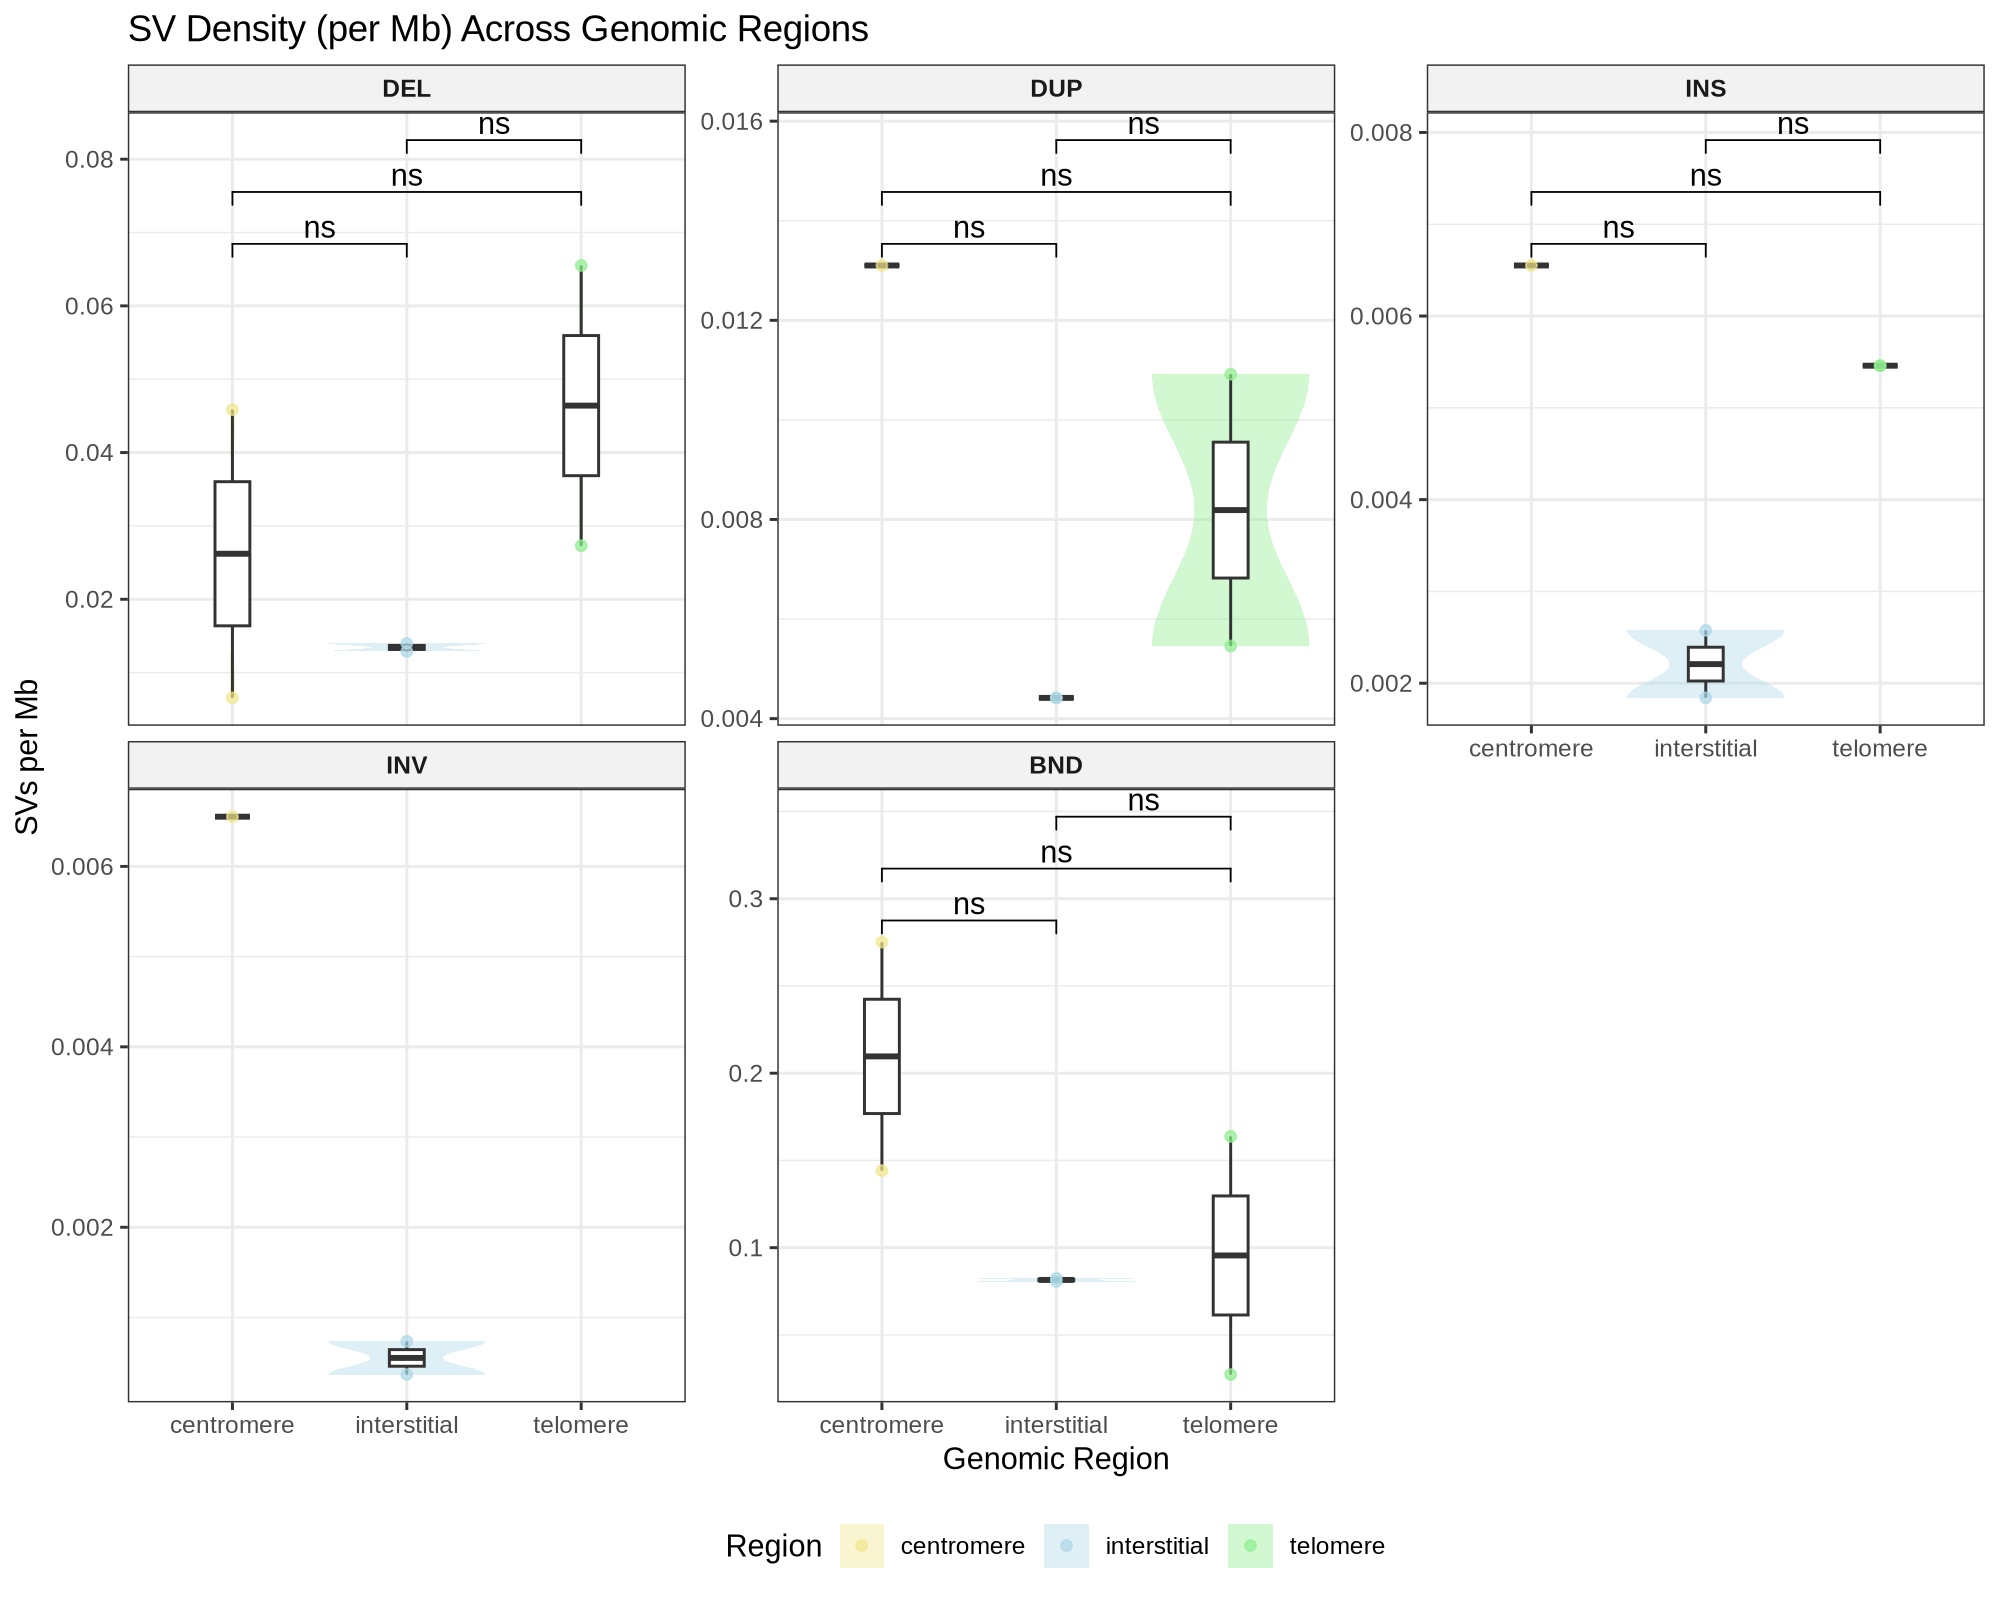

In [41]:
options(repr.plot.width = 10, repr.plot.height = 8, repr.plot.res = 200)


#–––– Plot ––––
p <- ggplot(sv_counts, aes(x = region, y = count_per_mb, fill = region)) +
  geom_violin(alpha = 0.4, color = NA) +
  geom_boxplot(width = 0.2, fill = "white", outlier.shape = NA) +
  geom_sina(aes(color = region), alpha = 0.7, size = 1.5) +
  stat_compare_means(
    comparisons = my_comparisons,
    method = "wilcox.test",
    label = "p.signif"
  ) +
  facet_wrap(~ type, nrow = 2, ncol = 3, scales = "free_y") +
  scale_fill_manual(values = c(
    centromere   = "khaki",
    interstitial = "lightblue",
    telomere     = "lightgreen"
  )) +
  scale_color_manual(values = c(
    centromere   = "khaki",
    interstitial = "lightblue",
    telomere     = "lightgreen"
  )) +
  labs(
    x = "Genomic Region",
    y = "SVs per Mb",
    fill = "Region",
    color = "Region",
    title = "SV Density (per Mb) Across Genomic Regions"
  ) +
  theme_bw() +
  theme(
    strip.background = element_rect(fill = "grey95"),
    strip.text = element_text(face = "bold"),
    legend.position = "bottom"
  )

print(p)
#ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig5/SV_density_regions_v3.pdf", plot = p, width = 8, height = 6)


Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message in wilcox.test.default(0.0131015258227928, c(0.00441624465936836, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.00441624465936836, 0.00441624465936836:
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(0.0065507629113964, c(0.00545896909283033, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.00257614271796488, 0.00184010194140348:
“cannot compute exact p-value with ties”
Warning message:
“Computation failed 

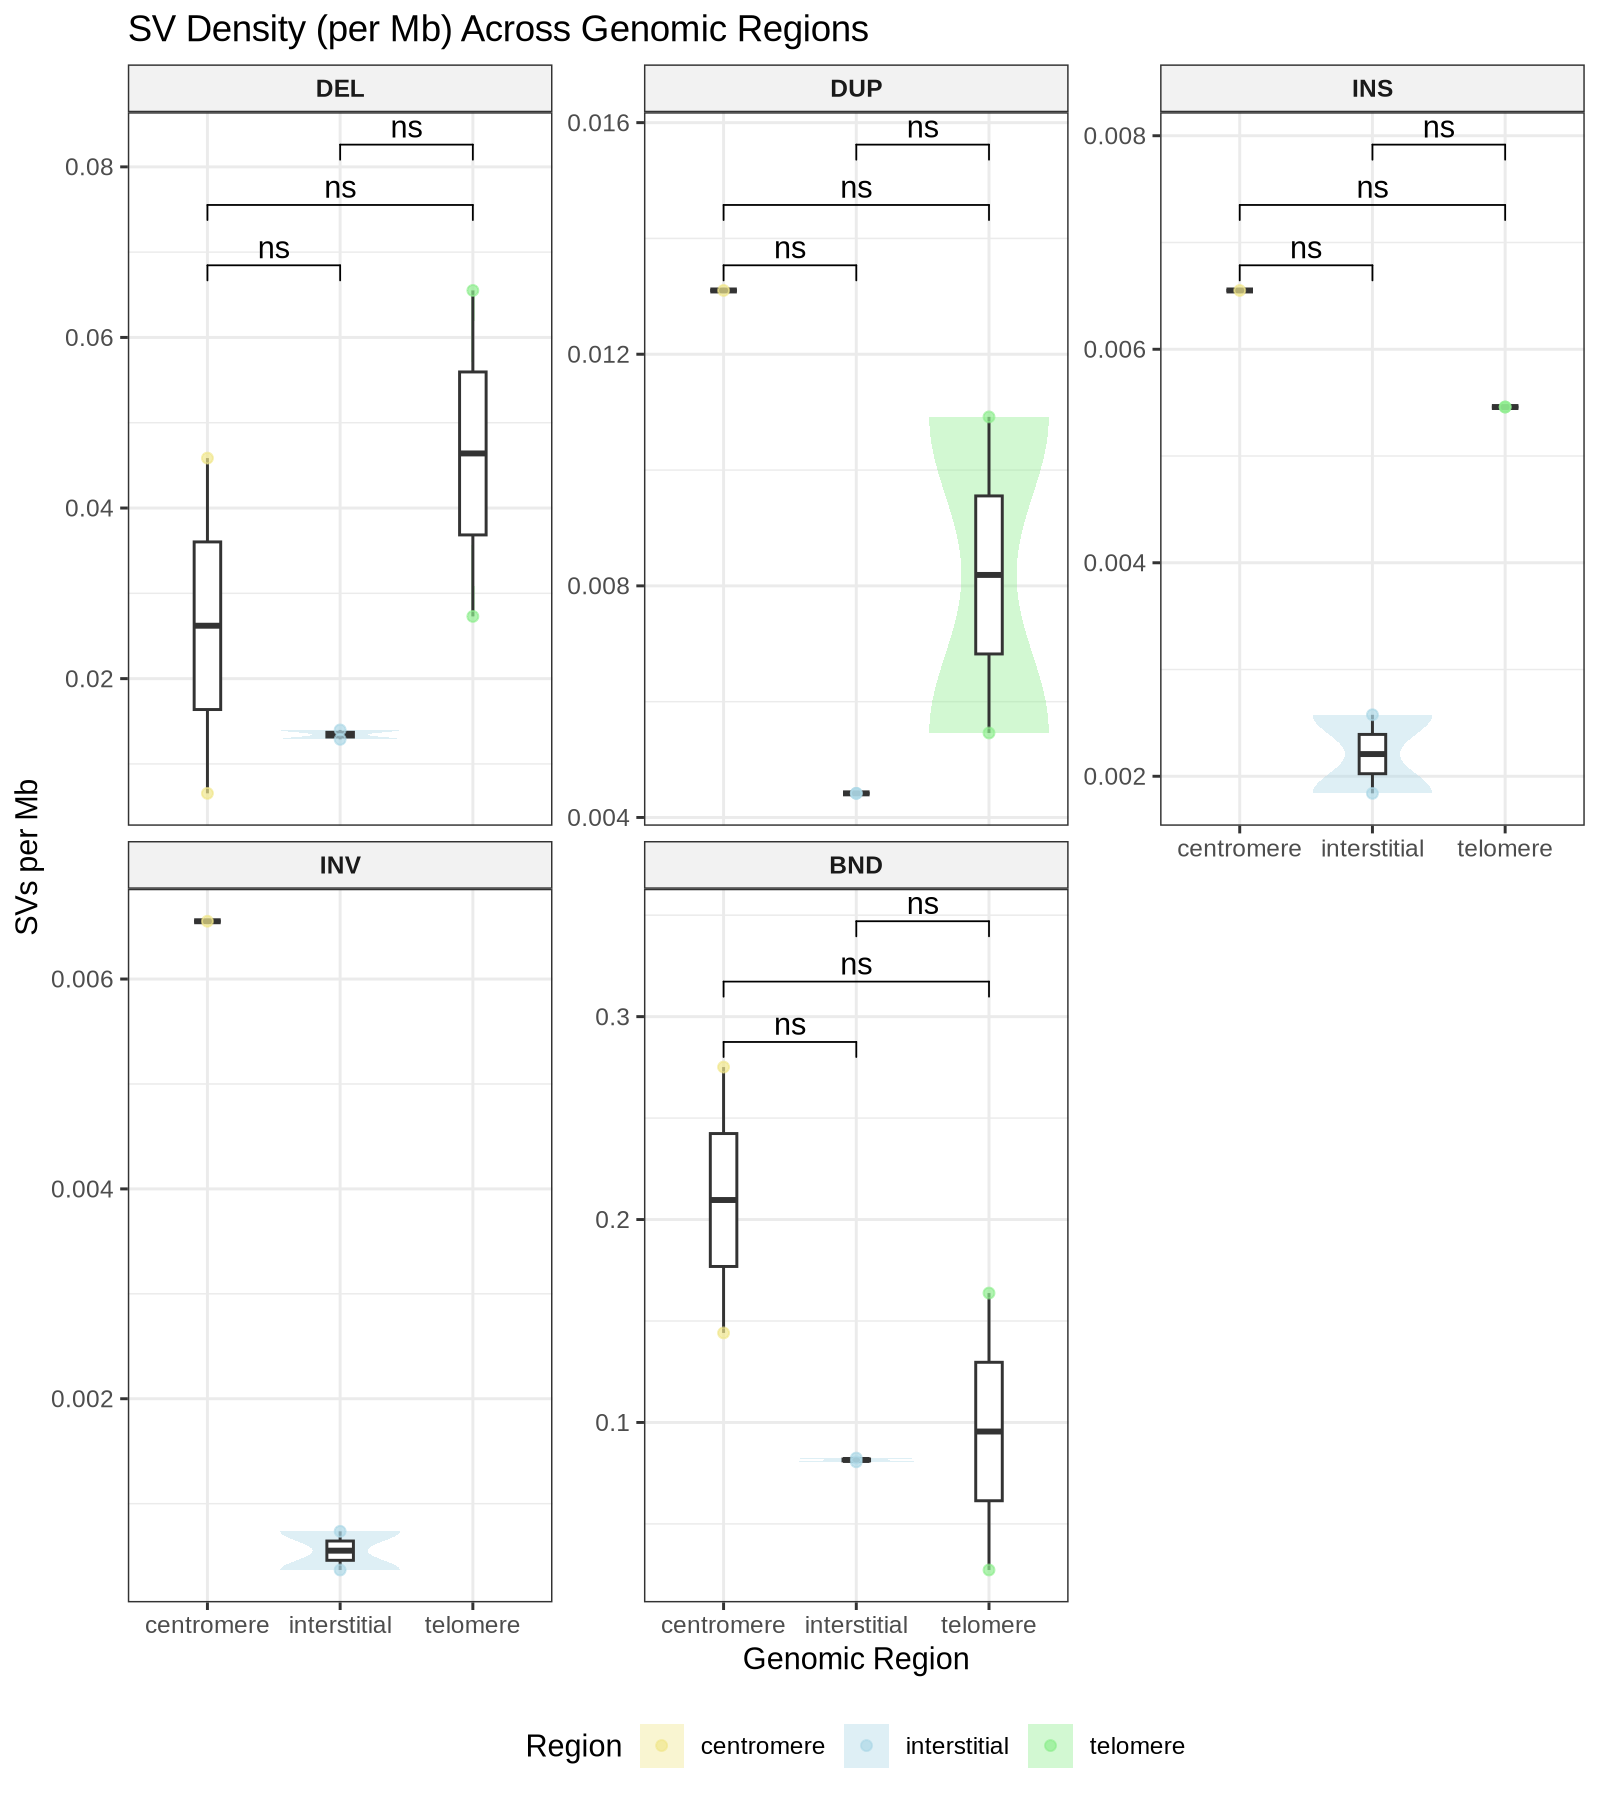

In [42]:
options(repr.plot.width = 8, repr.plot.height = 9, repr.plot.res = 200)

#pdf("/scratch/mjehangir/manuscript_figures/manuscript_data/plots_f4/SV_counts_centro_tel_distance_v3.pdf", width = 8, height = 9)
#––– print
print(p)
#dev.off()

In [43]:
region_lengths <- sv_categorized %>%
  distinct(chr, start_p, end_q) %>%  # One row per chromosome with coordinates
  mutate(
    chr_length = end_q - start_p,
    telo_length = chr_length * 0.03 * 2,   # telomere both ends
    centro_length = chr_length * 0.05,     # centromere length approx
    interstitial_length = chr_length - telo_length - centro_length
  ) %>%
  select(chr, telo_length, centro_length, interstitial_length) %>%
  pivot_longer(
    cols = c(telo_length, centro_length, interstitial_length),
    names_to = "region",
    values_to = "length_bp"
  ) %>%
  mutate(
    region = case_when(
      region == "telo_length" ~ "telomere",
      region == "centro_length" ~ "centromere",
      region == "interstitial_length" ~ "interstitial",
      TRUE ~ region
    ),
    length_mb = length_bp / 1e6
  )


In [44]:
head(region_lengths)

chr,region,length_bp,length_mb
<fct>,<chr>,<dbl>,<dbl>
chr1,telomere,14799082,14.799082
chr1,centromere,12332568,12.332568
chr1,interstitial,219519713,219.519713
chr10,telomere,8085488,8.085488
chr10,centromere,6737907,6.737907
chr10,interstitial,119934739,119.934739


In [45]:
sv_counts_chr <- sv_categorized %>%
  filter(region %in% c("centromere", "interstitial", "telomere")) %>%
  group_by(filename, chr, region, type) %>%
  summarise(sv_count = n(), .groups = "drop")


In [46]:
head(sv_counts_chr)

filename,chr,region,type,sv_count
<int>,<fct>,<chr>,<chr>,<int>
213,chr1,interstitial,BND,6
213,chr2,interstitial,DUP,2
213,chr3,interstitial,BND,4
213,chr3,interstitial,DEL,3
213,chr3,interstitial,DUP,1
213,chr3,interstitial,INS,1


In [66]:
sv_counts_chr_norm <- sv_counts_chr %>%
  left_join(region_lengths, by = c("chr", "region")) %>%
  mutate(count_per_mb = sv_count / length_mb)
head(sv_counts_chr_norm)

filename,chr,region,type,sv_count,length_bp,length_mb,count_per_mb
<int>,<fct>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
213,chr1,interstitial,BND,6,219519713,219.5197,0.027332397
213,chr2,interstitial,DUP,2,216000109,216.0001,0.009259255
213,chr3,interstitial,BND,4,178984294,178.9843,0.022348330
213,chr3,interstitial,DEL,3,178984294,178.9843,0.016761247
213,chr3,interstitial,DUP,1,178984294,178.9843,0.005587082
213,chr3,interstitial,INS,1,178984294,178.9843,0.005587082


In [48]:
library(ggplot2)
options(repr.plot.width = 15, repr.plot.height = 4, repr.plot.res = 200)



plot_chr <- function(chr_name) {
  data_sub <- sv_counts_chr_norm %>% filter(chr == chr_name)
  
  ggplot(data_sub, aes(x = region, y = count_per_mb, fill = region)) +
    geom_violin(alpha = 0.4, color = NA) +
    geom_boxplot(width = 0.2, fill = "white", outlier.shape = NA) +
    geom_sina(aes(color = region), alpha = 0.7, size = 1.5) +
    facet_wrap(~ type, nrow = 1, scales = "free_y") +   # one row, all SV types side by side
    scale_fill_manual(values = c(
      centromere = "khaki",
      interstitial = "lightblue",
      telomere = "lightgreen"
    )) +
    scale_color_manual(values = c(
      centromere = "khaki",
      interstitial = "lightblue",
      telomere = "lightgreen"
    )) +
    labs(
      title = paste0("SV Density per Mb - ", chr_name),
      x = "Genomic Region",
      y = "SVs per Mb",
      fill = "Region",
      color = "Region"
    ) +
    theme_bw() +
    theme(
      strip.background = element_rect(fill = "grey95"),
      strip.text = element_text(face = "bold"),
      legend.position = "bottom"
    )
}


In [49]:
library(ggpubr)

my_comparisons <- list(
  c("centromere", "interstitial"),
  c("centromere", "telomere"),
  c("interstitial", "telomere")
)


Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message in max(data$density, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”
Warning message:
“Computation failed in `stat_ydensity()`.
Caused by error in `$<-.data.frame`:
! replacement has 1 row, data has 0”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message in max(data$density, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”
Warning message:
“Computation failed in `st

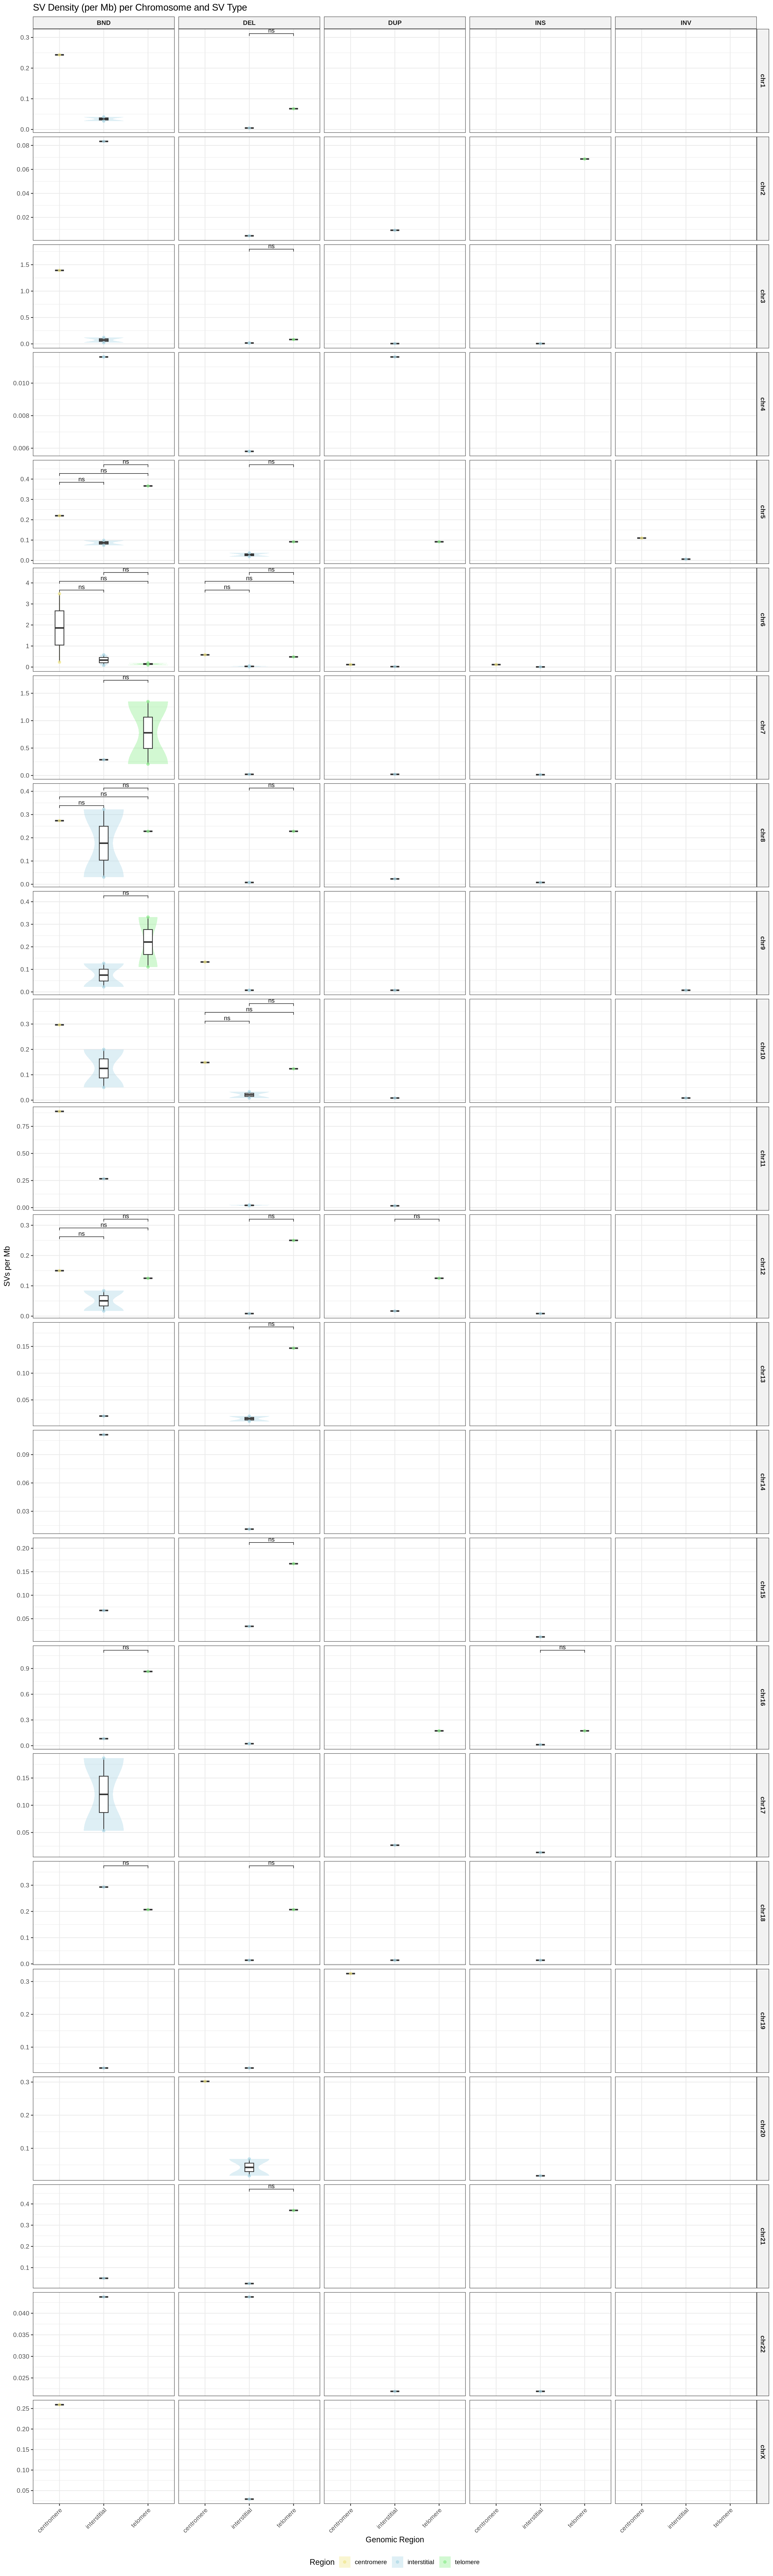

In [52]:
options(repr.plot.width = 15, repr.plot.height = 50, repr.plot.res = 200)

ggplot(sv_counts_chr_norm, aes(x = region, y = count_per_mb, fill = region)) +
  geom_violin(alpha = 0.4, color = NA) +
  geom_boxplot(width = 0.2, fill = "white", outlier.shape = NA) +
  geom_sina(aes(color = region), alpha = 0.7, size = 1.5) +
  facet_grid(chr ~ type, scales = "free_y") +
  stat_compare_means(
    comparisons = my_comparisons,
    method = "wilcox.test",
    label = "p.signif",
    label.y.npc = "top",  # places labels on top inside each facet
    size = 3
  ) +
  scale_fill_manual(values = c(
    centromere = "khaki",
    interstitial = "lightblue",
    telomere = "lightgreen"
  )) +
  scale_color_manual(values = c(
    centromere = "khaki",
    interstitial = "lightblue",
    telomere = "lightgreen"
  )) +
  labs(
    x = "Genomic Region",
    y = "SVs per Mb",
    fill = "Region",
    color = "Region",
    title = "SV Density (per Mb) per Chromosome and SV Type"
  ) +
  theme_bw() +
  theme(
    strip.background = element_rect(fill = "grey95"),
    strip.text = element_text(face = "bold"),
    legend.position = "bottom",
    axis.text.x = element_text(angle = 45, hjust = 1)
  )


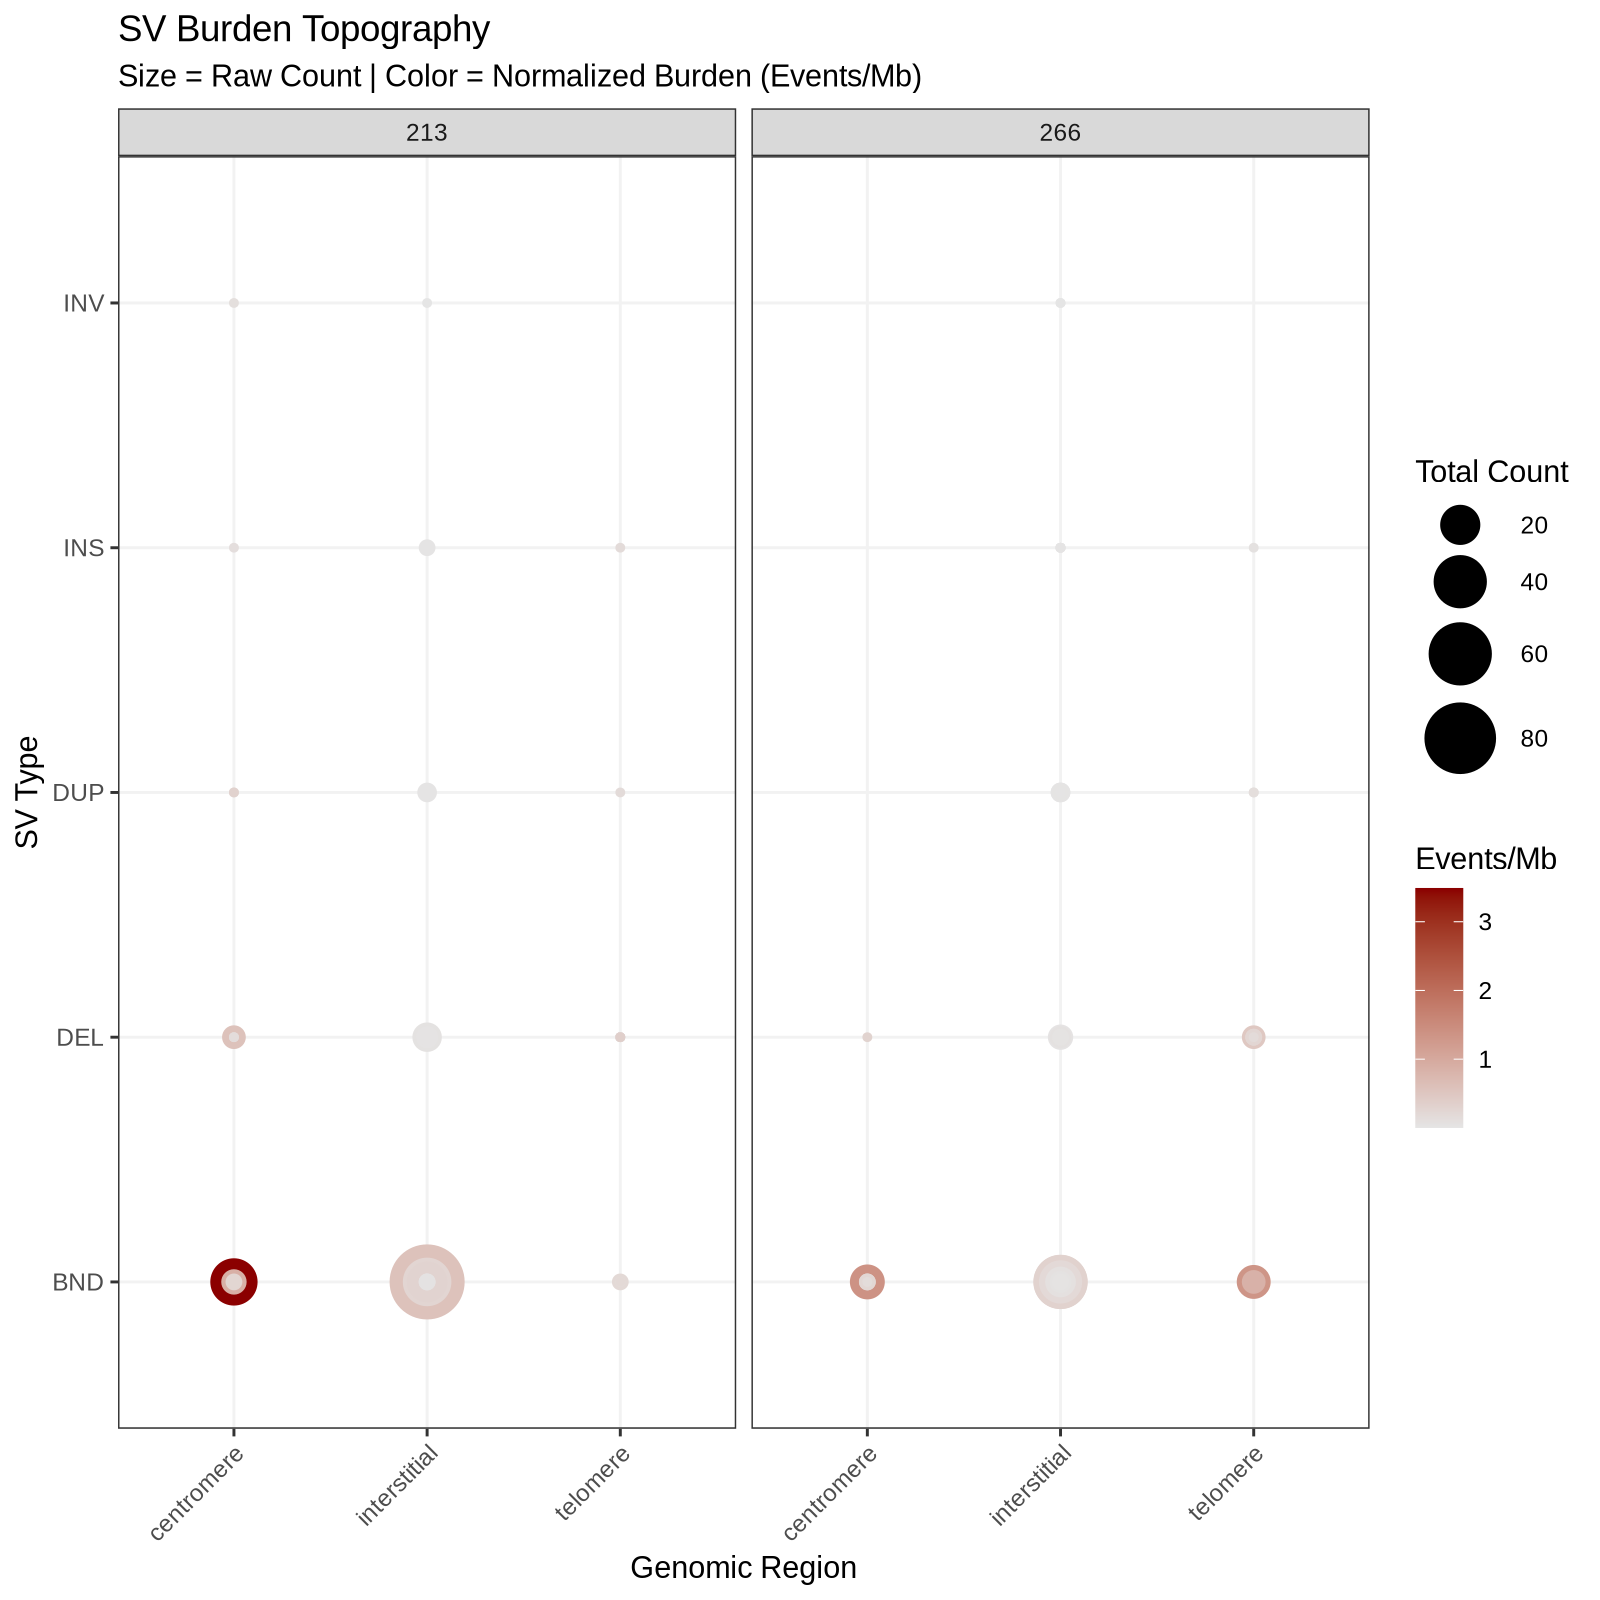

In [69]:
library(ggplot2)

ggplot(sv_counts_chr_norm, aes(x = region, y = type, size = sv_count, color = count_per_mb)) +
  geom_point() +
  facet_wrap(~filename) +
  # Customizing the look: bigger circles for higher burden
  scale_size_continuous(range = c(1, 12), name = "Total Count") +
  scale_color_gradient(low = "grey90", high = "darkred", name = "Events/Mb") +
  theme_bw() +
  labs(
    title = "SV Burden Topography",
    subtitle = "Size = Raw Count | Color = Normalized Burden (Events/Mb)",
    x = "Genomic Region",
    y = "SV Type"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major = element_line(color = "grey95")
  )